In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.graph_objects as go
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('ForeignGifts_edu.csv')
df.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


In [3]:
df_uva =df.loc[df["Institution Name"] == "University of Virginia"].copy()
df_uva


,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
26235,26236,374500,University of Virginia,Charlottesville,VA,41822,3565,Monetary Gift,ENGLAND,West Yorkshire Police
26236,26237,374500,University of Virginia,Charlottesville,VA,41870,12265,Contract,ISRAEL,CureTech Ltd
26237,26238,374500,University of Virginia,Charlottesville,VA,41873,8187,Monetary Gift,ISRAEL,Branco Weiss Institute
26238,26239,374500,University of Virginia,Charlottesville,VA,41887,6437,Contract,ISRAEL,NovoCure Ltd
26239,26240,374500,University of Virginia,Charlottesville,VA,41904,216943,Contract,ISRAEL,InSightec-Image Guide Treatment Ltd
...,...,...,...,...,...,...,...,...,...,...
26328,26329,374500,University of Virginia,Charlottesville,VA,43602,99885,Contract,SWEDEN,AutoLiv Development AB
26329,26330,374500,University of Virginia,Charlottesville,VA,43697,1000000,Monetary Gift,SWITZERLAND,Lawrence D & Karin S Howell
26330,26331,374500,University of Virginia,Charlottesville,VA,43796,500000,Monetary Gift,GUERNSEY,Harvest Group Holding (PTC Limited)
26331,26332,374500,University of Virginia,Charlottesville,VA,43803,146810,Contract,THE NETHERLANDS,Pantarhei Oncology BV


In [4]:
df_uva.describe()

,ID,OPEID,Foreign Gift Received Date,Foreign Gift Amount
count,98.000000,98.0,98.000000,9.800000e+01
mean,26284.500000,374500.0,42671.408163,2.264208e+05
std,28.434134,0.0,521.746904,3.433051e+05
min,26236.000000,374500.0,41822.000000,3.100000e+01
25%,26260.250000,374500.0,42301.250000,9.450000e+03
50%,26284.500000,374500.0,42553.500000,8.053550e+04
75%,26308.750000,374500.0,43029.750000,2.768882e+05
max,26333.000000,374500.0,43818.000000,1.708021e+06


Country Giftor of UVA

In [36]:
df_uva["Country of Giftor"].unique()

<StringArray>
[        'ENGLAND',          'ISRAEL',      'BANGLADESH',          'SWEDEN',
           'JAPAN',           'KOREA',       'SINGAPORE', 'THE NETHERLANDS',
         'BERMUDA',         'FINLAND',        'TANZANIA',          'RWANDA',
        'GUERNSEY',          'FRANCE',     'SWITZERLAND']
Length: 15, dtype: str

Gift type of UVA

In [6]:
df_uva["Gift Type"].value_counts()

Gift Type
Contract         64
Monetary Gift    34
Name: count, dtype: int64

Top 10 countries Giving to UVA

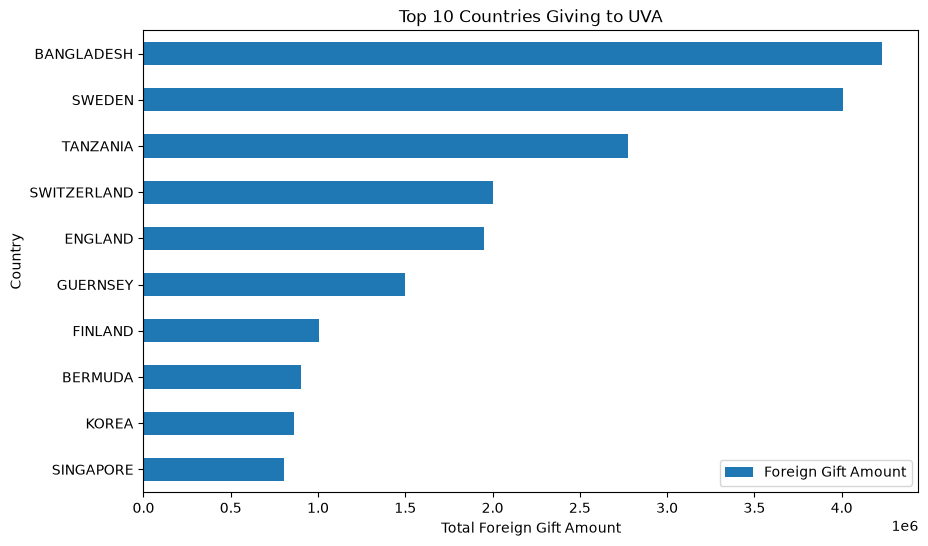

In [7]:
uva_by_country = (df_uva[["Country of Giftor","Foreign Gift Amount"]].groupby(["Country of Giftor"]).sum().sort_values(by="Foreign Gift Amount", ascending=False).head(10))
uva_by_country.sort_values("Foreign Gift Amount").plot(kind="barh",figsize=(10, 6))

plt.xlabel("Total Foreign Gift Amount")
plt.ylabel("Country")
plt.title("Top 10 Countries Giving to UVA")
plt.show()


In [31]:
qatar = df[df["Country of Giftor"].str.contains("Qatar", case=False, na=False)]

qatar["Gift Type"].value_counts()

Gift Type
Contract         586
Monetary Gift    107
Name: count, dtype: int64

We can see Bangladesh gave a total of $4,228,589 

In [8]:
df_uva[["Country of Giftor","Foreign Gift Amount"]].groupby(["Country of Giftor"]).count().sort_values(by="Foreign Gift Amount", ascending=False)

,Foreign Gift Amount
Country of Giftor,
ENGLAND,31
ISRAEL,12
BANGLADESH,10
SWEDEN,10
FINLAND,7
KOREA,6
FRANCE,5
THE NETHERLANDS,4
GUERNSEY,3


In [9]:
uva_total = df_uva["Foreign Gift Amount"].sum()
uva_total

np.int64(22189238)

UVA's Foreign Gift Amount is $22189238

In [10]:
uva_gift_count = df_uva["Foreign Gift Amount"].count()
uva_gift_count

np.int64(98)

UVA received donations 98 times 

In [11]:
df_uva["Foreign Gift Amount"].mean()

np.float64(226420.79591836734)

In [12]:
df_uva["Foreign Gift Amount"].median()

np.float64(80535.5)

UVA receives many smaller-to-moderate foreign gifts, while a few very large gifts substantially increase the average gift amount.

In [13]:
df["Institution Name"].unique()

<StringArray>
[                       'Jacksonville State University',
                                      'Troy University',
                                'University of Alabama',
                  'University of Alabama at Birmingham',
                          'University of South Alabama',
                             'Arizona State University',
                          'Northern Arizona University',
                          'University of Arizona (The)',
                               'University of Arkansas',
                                     'Biola University',
 ...
                      'DigiPen Institute of Technology',
                           'Soka University of America',
     'Keck Graduate Institute of Applied Life Sciences',
                         'Columbia Southern University',
                     'University of California, Merced',
                   'Hult International Business School',
                             'Presidio Graduate School',
          'C

In [14]:
institutions_peers = df.loc[df["State"].isin(["DC", "VA", "MD"]), "Institution Name"].unique()
df_peers = df[df["Institution Name"].isin(institutions_peers)]
df_peers

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
10965,10966,143400,American University (The),Washington,DC,41753,1000000,Monetary Gift,ENGLAND,Anonymous
10966,10967,143400,American University (The),Washington,DC,42107,1000000,Monetary Gift,ENGLAND,NaN
10967,10968,143400,American University (The),Washington,DC,42173,989000,Monetary Gift,JAPAN,Nippon Foundation
10968,10969,143400,American University (The),Washington,DC,42257,500000,Monetary Gift,KUWAIT,NaN
10969,10970,143700,Catholic University of America (The),Washington,DC,43585,7572000,Contract,SAUDI ARABIA,Saudi Arabian Cultural Mission
...,...,...,...,...,...,...,...,...,...,...
26390,26391,375400,Virginia Polytechnic Institute & State University,Blacksburg,VA,43692,1408507,Contract,SPAIN,ISGlobal
26391,26392,375400,Virginia Polytechnic Institute & State University,Blacksburg,VA,43766,321763,Contract,CANADA,Terrestrial Energy Inc.
26392,26393,375400,Virginia Polytechnic Institute & State University,Blacksburg,VA,43773,268310,Contract,CANADA,Terrestrial Energy Inc.
26393,26394,375400,Virginia Polytechnic Institute & State University,Blacksburg,VA,43794,350000,Contract,CHINA,CSR Zhruzhou Institute Co Ltd


In [15]:
df_peers["Institution Name"].unique()

<StringArray>
[                        'American University (The)',
              'Catholic University of America (The)',
                      'George Washington University',
                             'Georgetown University',
                   'Washington Adventist University',
                        'Frostburg State University',
                          'Johns Hopkins University',
                                 'Towson University',
              'University of Maryland, College Park',
                 'University of Maryland, Baltimore',
                         'College of William & Mary',
                  'Virginia Commonwealth University',
                            'University of Virginia',
                           'George Mason University',
 'Virginia Polytechnic Institute & State University']
Length: 15, dtype: str

In [16]:
peer_totals = (df_peers.groupby("Institution Name")["Foreign Gift Amount"].sum().sort_values(ascending=False))
peer_totals

Institution Name
Johns Hopkins University                             502409595
Georgetown University                                379950511
George Washington University                         157668354
Virginia Commonwealth University                      89163583
George Mason University                               65435604
University of Maryland, Baltimore                     46751866
University of Maryland, College Park                  29933278
University of Virginia                                22189238
Virginia Polytechnic Institute & State University     11792062
Catholic University of America (The)                   9423067
American University (The)                              3489000
College of William & Mary                              3384498
Washington Adventist University                        1581497
Towson University                                      1128687
Frostburg State University                              334023
Name: Foreign Gift Amount, dtype: int6

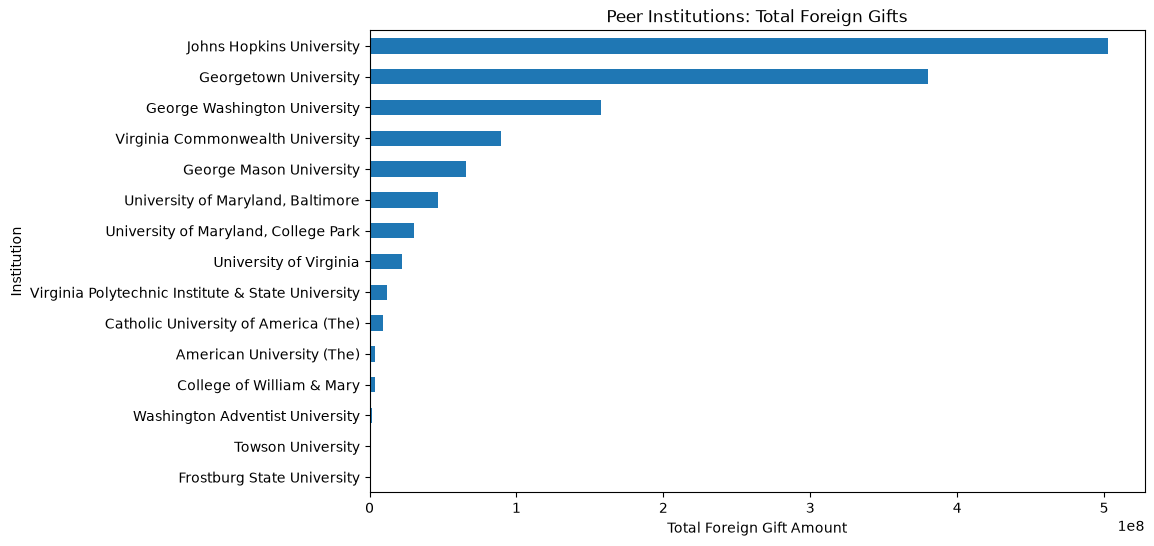

In [17]:
peer_totals.sort_values().plot(kind="barh", figsize=(10, 6))
plt.xlabel("Total Foreign Gift Amount")
plt.ylabel("Institution")
plt.title("Peer Institutions: Total Foreign Gifts")
plt.show()

We compare UVA to other DMV's universities. UVA stands in the middle 

**Quantive Analysis**

In [20]:
peer_totals.describe()


count    1.500000e+01
mean     8.830899e+07
std      1.513561e+08
min      3.340230e+05
25%      3.436749e+06
50%      2.218924e+07
75%      7.729959e+07
max      5.024096e+08
Name: Foreign Gift Amount, dtype: float64

In [22]:
#Difference between UVA and overall university mean
df['Foreign Gift Amount'].mean() /df_uva['Foreign Gift Amount'].mean()

np.float64(2.597962412778382)

In [37]:
country_counts = (
df[df["Institution Name"].isin(top_20["Institution Name"])]
.groupby("Institution Name")["Country of Giftor"]
.nunique()
.reset_index(name="Number of Countries")
)

top_20_with_country_counts = top_20.merge(
country_counts,
on="Institution Name"
)
top_20_with_country_counts

NameError: name 'top_20' is not defined

**Strategy**
(this is visualization is coming from initial_analysis notebook)

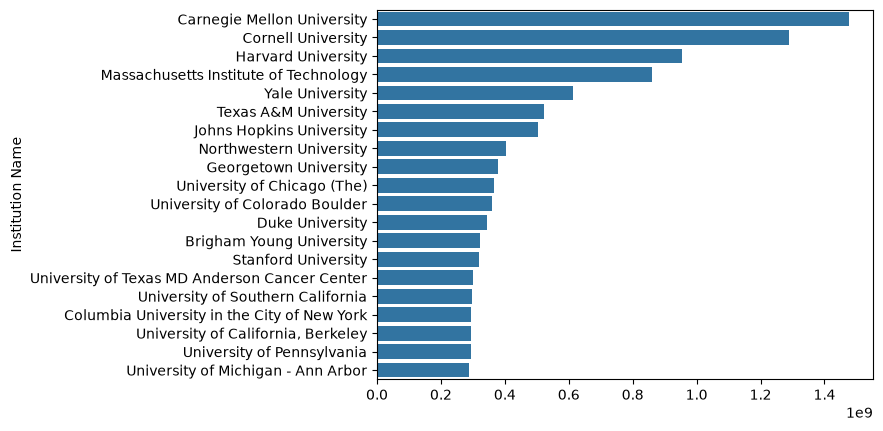

We found one tbhing that all these universities share in common, they have a big funding for research which is around $1.2–$1.5 billion per year on research. On the other hand UVA spends only $700–$800 million per year for research. So our proposed strategy is to dedicate more funds toward research, and we think that would increase the amount of donation that UVA will receive.